# How NYC Landlord Resolution works

This notebook walks through the landlord resolution algorithm step-by-step, following the arc of the official
[Splink tutorial](https://moj-analytical-services.github.io/splink/demos/tutorials/00_Tutorial_Introduction.html).

| Splink tutorial step | NYC Landlord Resolution |
|---|---|
| 1. Data prep prerequisites | `ss.extract` — owner contacts → one row per identity |
| 2. Exploratory analysis | fragmentation, name rarity, aggregator addresses |
| 3. Choosing blocking rules | the one name-anchored block |
| 4. Estimating model parameters | `ss.fit` — comparisons + λ/u/EM training |
| 5. Predicting results | `linker.predict` → scored pairs + waterfall |
| 6. Visualising predictions | `ss.cluster_gated` / `ss.build_portfolios` — the reunited portfolio |
| 7. Evaluation | gold-set precision/recall + `owner_index` |

## The problem

NYC requires building owners to register with HPD every year; the
same operator ends up scattered across many registrations — typo'd names (`STEVEN` vs `STEVE
CROMAN`, `BROADWAY` vs `BROADAWAY`) and several business offices — so one owner's buildings
fragment across separate "portfolios." That fragmentation is the **false-split** problem. nlr
resolves *who is who* probabilistically (Fellegi–Sunter, via Splink) from **two HPD tables
alone** `hpd_contacts` and `hpd_registrations`.

## Setup

nlr runs on the raw `hpd_contacts` + `hpd_registrations` tables. `default_conn()` connects to Postgres (`.env`: `PGHOST/PGPORT/PGDATABASE/PGUSER/PGPASSWORD`) or, with `NLR_SNAPSHOT` set, to a local DuckDB parquet snapshot — the resolution SQL is dialect-dispatched, so every call below runs unchanged on either backend.

In [24]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("splink").setLevel(logging.WARNING)   # quiet Splink's training chatter

import pandas as pd
pd.set_option("display.max_columns", 40, "display.width", 200)

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))     # find repo-root .env regardless of kernel cwd

from nlr import splink_source as ss, owner_index
from nlr.db import default_conn

conn = default_conn()
print("connected")

connected


## 1. Data prep prerequisites

> *Splink tutorial:* your data must be one row per record, each with a **unique id**, columns
> standardised and cleaned, and missing values as nulls.

`ss.extract(conn, where)` is nlr's data-prep step. It reads the qualifying **owner** contacts
(`HeadOfficer / IndividualOwner / CorporateOwner / JointOwner` — never agents/managers, which are
shared across unrelated landlords) and returns **one row per distinct identity**: a
`(kind, name, business address)` tuple, with that identity's buildings (`bbls`) aggregated.

Let's pull one landlord — Steven Croman — and look at the shape:

In [25]:
croman = ss.extract(conn, "upper(btrim(c.lastname)) = 'CROMAN'")
croman = croman[croman.contact_kind == "person"]
croman[["name_full", "biz_house", "biz_street", "biz_zip", "n_bbls"]] \
    .sort_values("n_bbls", ascending=False).reset_index(drop=True)

,name_full,biz_house,biz_street,biz_zip,n_bbls
0,STEVEN CROMAN,424,WEST 51ST STREET,10019,78
1,STEVEN CROMAN,424,WEST 51ST STREET,10019,30
2,STEVE CROMAN,424,WEST 51ST STREET,10019,3
3,STEVEN CROMAN,424,WEST 51ST STREET,10003,3
4,STEVE CROMAN,740,BROADWAY,10003,2
5,STEVEN CROMAN,424,WEST 51ST STREET,10019,2
6,STEVEN CROMAN,4,WEST 51ST STREET,10019,1
7,STEVEN CROMAN,424,BROADWAY,10019,1
8,STEVEN CROMAN,424,WEST 22ND STREET,10019,1
9,STEVEN CROMAN,424,WEST 51ST STREET,10003,1


**One person, many rows** — `STEVEN CROMAN` / `STEVE CROMAN` across several offices. That is the
fragmentation we need to resolve. Note the columns the extraction prepares for matching:

- **`unique_id`** — a deterministic `md5` of the identity, so a re-run yields the same ids.
- **`name_normalized`** — the name with a trailing `LLC/INC/CORP/…` suffix stripped.
- **`biz_street_norm`** — the street with its type suffix removed (`WEST 21ST STREET` → `WEST 21ST`),
  so a dropped "STREET" doesn't defeat the match.
- **`first_initial`**, **`biz_apt_num`**, **`biz_zip`** — the remaining comparison fields.
- missing fields are genuine **nulls** (via `NULLIF`), so a comparison is skipped, not matched on `''`.

Why this **grain** (one row per identity, `bbls` aggregated) rather than one row per building? So
term-frequency reflects *name rarity*, not portfolio size — and so the fragments WoW split are
preserved as separate rows for Splink to link back together.

In [26]:
# The full prepared record for Croman's largest-footprint identity:
croman.sort_values("n_bbls", ascending=False).iloc[0]

unique_id                           4100d690af541946ca1d870bd5c5e53c
contact_kind                                                  person
name_full                                              STEVEN CROMAN
first_name                                                    STEVEN
last_name                                                     CROMAN
name_normalized                                        STEVEN CROMAN
biz_house                                                        424
biz_street                                          WEST 51ST STREET
biz_apt                                                           GF
biz_apt_num                                                      NaN
biz_city                                                    NEW YORK
biz_state                                                         NY
biz_zip                                                        10019
biz_street_norm                                            WEST 51ST
first_initial                     

## 2. Exploratory analysis

> *Splink tutorial:* profile your columns — missingness, cardinality, skew — *before* choosing
> comparisons and blocking, because those choices depend on the data.

nlr's three population signals are exactly this profiling, and each one drives a later modelling
decision.

**(a) Name rarity → why term-frequency matters.** A rare surname matching across offices is almost
surely one person; a common one might be several. `ss.name_freq` counts distinct identities per
`(last_name, first_initial)`:

In [27]:
nf = ss.name_freq(conn)
def rarity(last, init):
    row = nf[(nf.last_name == last) & (nf.first_initial == init)]
    return int(row.identities.iloc[0]) if len(row) else 0
print("distinct identities sharing a (surname, initial):")
for last, init in [("CROMAN","S"), ("RASHAD","J"), ("SMITH","J"), ("CHEN","J")]:
    print(f"  {last:<8} {init}:  {rarity(last, init):>4}")
nf.identities.describe()

distinct identities sharing a (surname, initial):
  CROMAN   S:     8
  RASHAD   J:     1
  SMITH    J:    25
  CHEN     J:   232


count    81232.000000
mean         1.732593
std          3.564472
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        232.000000
Name: identities, dtype: float64

`CROMAN, S` is a handful; `SMITH, J` is 10s and `CHEN, J` is hundreds. That skew is why the model uses
**term-frequency adjustments** on names — a match on a rare name is weighted far more than on a
common one, the lever WoW's rules lack.

**(b) Aggregator addresses → why we mask.** Some "business addresses" are registered-agent offices
or filing services shared by *hundreds* of unrelated landlords — matching on them fuses different
owners. `ss.address_degrees` counts distinct landlords per address:

In [28]:
degs = ss.address_degrees(conn)
n_agg = (degs.addr_degree > ss.AGGREGATOR_DEGREE).sum()
print(f"AGGREGATOR_DEGREE threshold = {ss.AGGREGATOR_DEGREE}")
print(f"addresses over threshold (masked as aggregators): {n_agg:,} of {len(degs):,}")
degs.sort_values("addr_degree", ascending=False).head(8).reset_index(drop=True)

AGGREGATOR_DEGREE threshold = 25
addresses over threshold (masked as aggregators): 83 of 101,244


,biz_house,biz_street_norm,addr_degree
0,909,THIRD,281
1,575,FIFTH,229
2,156,WEST 56TH,225
3,9,EAST 38TH,181
4,254,WEST 31ST,158
5,770,LEXINGTON,138
6,210,EAST 23RD,137
7,1995,BROADWAY,124


Those top addresses are shared by hundreds of distinct landlords — clearly offices, not owners.
`ss.fit(..., addr_degrees=degs)` **blanks the address columns** of any address above the threshold,
so its records can still link on *name*, but a shared aggregator address no longer merges strangers.

## 3. Choosing blocking rules to optimise runtimes

> *Splink tutorial:* you can't score all N² pairs — **blocking** restricts scoring to candidate
> pairs that satisfy a rule, trading a little recall for a lot of speed.

nlr uses a single, deliberately **name-anchored** blocking rule: two records are compared only if
they share a **last name + first initial**. Landlord resolution keys on the *person*, so a surname
match is required even to score a pair; the first-initial gate stops different-first-name namesakes
at one address (`DIVYA` vs `JAMAL`), while `STEVE`/`STEVEN` share an initial and still merge.

In [29]:
import inspect
src = inspect.getsource(ss._settings)
print(src.split("blocking_rules_to_generate_predictions")[1].split("retain_intermediate")[0].strip())

=[
            block_on("last_name", "first_initial"),
        ],


This is a **precision** decision, not just a runtime one. An address-only rule
(`biz_house + biz_street_norm + first_initial`) used to be here too — and at full-population scale it
fused **2,044 clusters** of different people who merely shared an office and an initial (`JOEL
BRAVER` + `JACOB GUTMAN`). Removing it zeroed those out at *no* cost to recall (Croman/Rashad still
consolidate via the name rule + term-frequency). Trade-off: pure surname *typos* are no longer
candidates — a known, accepted limitation.

## 4. Estimating model parameters

> *Splink tutorial:* define **comparisons** (how each column is compared, at graduated fuzzy
> levels), then estimate the model — `u` by random sampling, `m` by expectation-maximisation, and
> the prior λ (probability two random records match).

nlr's comparisons (`ss._settings`) fuzzy-match exactly the fields that break WoW's exact rules:

In [30]:
print(src.split("comparisons=[")[1].split("],")[0].strip())

# Term-frequency on names: a rare "CROMAN"/"RASHAD" match counts far more
            # than a common one — the lever WoW's rules lack. TF is computed over the
            # predicted population, so predict on the full set (or a representative
            # sample), not a target-heavy slice, or every target name looks "common".
            cl.JaroWinklerAtThresholds("last_name", [0.92, 0.85]).configure(term_frequency_adjustments=True),
            cl.JaroWinklerAtThresholds("first_name", [0.92, 0.80]).configure(term_frequency_adjustments=True),
            # Component address (house Levenshtein for "4"/"424", street fuzzy for
            # "BROADWAY"/"BROADAWAY", zip exact + TF). Aggregator down-weighting is a
            # later refinement — the composite-address attempt broke merging.
            cl.LevenshteinAtThresholds("biz_house", [1, 2]),
            # Compare the *suffix-normalized* street ("WEST 21ST STREET" == "WEST 21ST")
            # so a tight fuzzy threshold still catch

- **names** — Jaro–Winkler at graduated thresholds **with term-frequency adjustments** (the rarity
  lever from step 2);
- **`biz_house`** — Levenshtein (so `4` ↔ `424`, `666` typos, are near-matches);
- **`biz_street_norm`** — Jaro–Winkler (so `BROADWAY` ↔ `BROADAWAY`);
- **`biz_zip`** — exact, with term-frequency.

`ss.fit` masks aggregator addresses, then trains: λ is anchored on same-name-**and**-address pairs,
`u` by random sampling, and two EM passes triangulate `m` (block on the name to learn address
weights, block on the address to learn name weights). First, build a **working slice** — a dense mix
of the gold operators, their address-neighbours, shared-office co-mates, and a ~1% random base (so
term-frequency sees a realistic population):

In [31]:
from nlr.eval.build_gold import TARGET_WHERE, NBR_WHERE, OFFICE_WHERE

df = pd.concat([
    ss.extract(conn, TARGET_WHERE),         # gold operators (Croman, Rashad, Castellano, Kadden)
    ss.extract(conn, NBR_WHERE),            # their address-neighbours (decoys + real co-mates)
    ss.extract(conn, OFFICE_WHERE),         # shared-office co-mates (the hard negatives)
    ss.extract(conn, "random() < 0.01"),   # ~1% random base for realistic term-frequency
], ignore_index=True)
df = df[df.contact_kind == "person"].drop_duplicates("unique_id").reset_index(drop=True)
print(f"{len(df):,} identities in the working slice")

2,432 identities in the working slice


In [32]:
linker, preds = ss.fit(df, addr_degrees=degs)     # mask aggregators + train (λ, u, two EM passes)
print("model trained")

Probability two random records match is estimated to be  5.07e-05.
This means that amongst all possible pairwise record comparisons, one in 19,707.31 are expected to match.  With 2,956,096 total possible comparisons, we expect a total of around 150.00 matching pairs
----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - last_name (no m values are trained).
    - first_name (no m values are trained).
    - biz_house (no m values are trained).
    - biz_street_norm (no m values are trained).
    - biz_zip (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
(l."first_name" = r."first_name") AND (l."last_name" = r."last_name")

Parameter estimates will be made for the following comparison(s):
    - biz_house
    - biz_street_norm
    - biz_zip

Parameter estimates cannot be made for the follow

model trained


The trained model's **match weights** — how much each comparison level moves the score — the same chart the Splink tutorial produces:

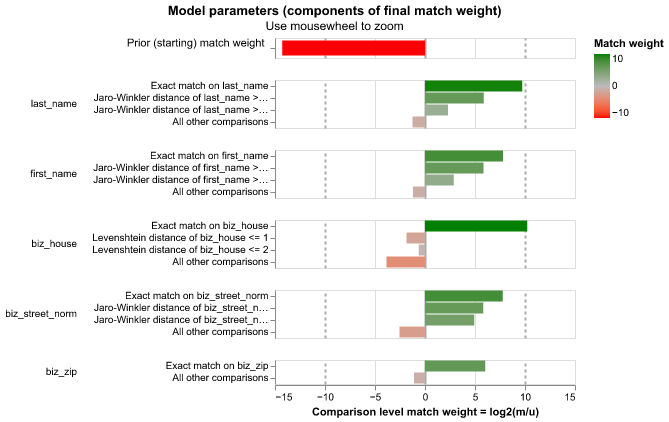

In [33]:
# The "mimetype" renderer depends on a notebook extension (e.g. Jupyter
# Renderers) understanding whatever Vega-Lite schema version Altair emits,
# and VS Code's extension doesn't yet support the v6 specs this Altair
# version produces. "png" rasterizes locally via vl-convert, with no
# dependency on the frontend at all.
import altair as alt
alt.renderers.enable("png")

linker.visualisations.match_weights_chart()

*(Note on scale: on the full ~145k-identity population, Splink's λ collapses toward zero and
under-merges even identical records — the "low-λ trap." nlr's production path,
`ss.fit_predict_full` / `owner_index`, trains on a dense slice like this one and transfers the model
onto the full set, where term-frequency recomputes population-wide. Step 7 uses `owner_index`.)*

## 5. Predicting results

> *Splink tutorial:* `linker.inference.predict()` scores the candidate pairs; a **waterfall chart**
> shows *why* a given pair scored the way it did.

`ss.fit` already ran `predict` at a permissive threshold (so we can cluster at any higher threshold
without re-scoring). Here are the scored pairs:

In [34]:
pred_df = preds.as_pandas_dataframe()
print(f"{len(pred_df):,} candidate pairs scored")
# Splink emits `_l`/`_r` only for the columns it COMPARES (last_name, first_name,
# biz_street_norm, biz_house, biz_zip) — not passthrough columns like name_full.
pred_df[["match_probability", "match_weight",
         "first_name_l", "last_name_l", "first_name_r", "last_name_r",
         "biz_street_norm_l", "biz_street_norm_r"]] \
    .sort_values("match_probability", ascending=False).head(8).reset_index(drop=True)

283 candidate pairs scored


,match_probability,match_weight,first_name_l,last_name_l,first_name_r,last_name_r,biz_street_norm_l,biz_street_norm_r
0,1.0,28.325274,NATHANIEL,RAHAV,NATHANIEL,RAHAV,WEST 15TH,WEST 15TH
1,1.0,28.047741,MARLA,SIEGEL,MARLA,SIEGEL,SPRING,SPRING
2,1.0,27.977351,HERSEL,TORKIAN,HERSEL,TORKIAN,BROADWAY,BROADWAY
3,1.0,27.018016,STEVEN,FINKELSTEIN,STEVE,FINKELSTEIN,BROOK,BROOK
4,1.0,26.910237,LEIB,SPITZER,LEIB,SPITZER,SPENCER,SPENCER
5,1.0,25.740312,SHLOMO,KUBITSHUK,SHLOMO,KUBITSHUK,SPENCER,SPENCER
6,1.0,25.592766,HYMAN,SCHATTNER,HYMAN,SCHATTNER,AVE M,AVENUE M
7,1.0,25.588309,AMRAM,LEVY,AMRAM,LEVY,SPENCER,SPENCER


A **waterfall** for Croman's top-scoring pairs — each bar is one comparison's contribution to the total match weight (the human-readable *why*):

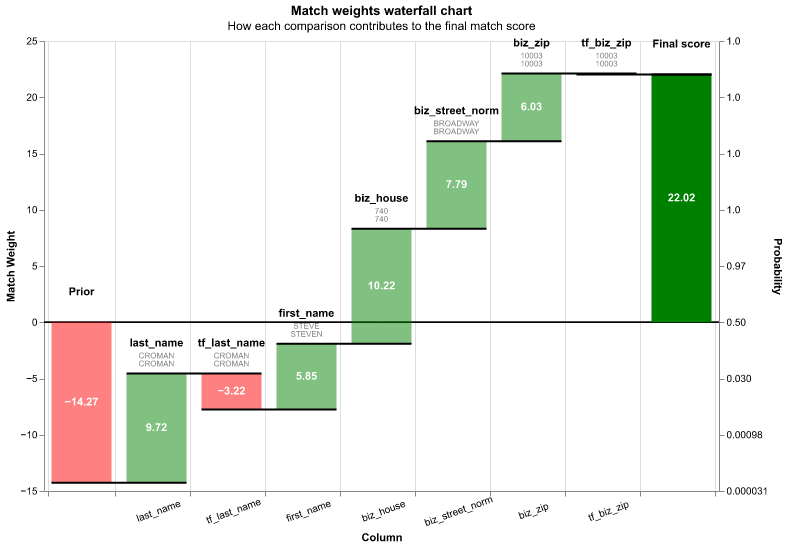

In [35]:
croman_pairs = pred_df[(pred_df.last_name_l == "CROMAN") &
                       (pred_df.last_name_r == "CROMAN")] \
                 .sort_values("match_probability", ascending=False)
linker.visualisations.waterfall_chart(croman_pairs.head(1).to_dict("records"))

## 6. Visualising predictions

> *Splink tutorial:* turn pairwise scores into **clusters** (connected components at a threshold)
> and inspect them (cluster studio / comparison viewer).

nlr clusters with `ss.cluster_gated`, which adds two precision **vetoes** on top of connected
components: a **first-name veto** (drop an edge whose first names genuinely disagree — `JACOB` vs
`JOSEF GUTMAN`) and a **common-name veto** (don't merge a common full name across *different*
addresses). Did Croman consolidate?

In [36]:
clusters = ss.cluster_gated(preds, df, threshold=0.92, name_freq=nf)

croman_clusters = (clusters[clusters.name_full.str.contains("CROMAN")]
                   .groupby("cluster_id")
                   .agg(records=("unique_id", "size"),
                        example_name=("name_full", "first"),
                        offices=("biz_street", "nunique")))
croman_clusters

,records,example_name,offices
cluster_id,,,
71d3a04d50b4cba68f4754a8a8d2c827,5,STEVE CROMAN,1
9848e41941107b9a763a44896154f88a,9,STEVE CROMAN,3
f426755e759117a1d1649d3c6fd752cd,1,STEVEN CROMAN,1


Not quite — a **dominant cluster** plus two smaller fragments. `ss.cluster_gated` links only what name + address agreement can reach *directly*, so offices that never share an address stay apart. `owner_index` closes that gap with a **corporate-co-owner feedback pass**:

In [38]:
# Why 2 clusters, not 1? cluster_gated links only what name + address reach directly. owner_index
# then runs a corporate-co-owner FEEDBACK pass: it bridges same-name offices that share a private
# corporate co-owner — Croman's offices tie together through Centennial Properties, a link no
# address match can make. (owner_index applies this by default, feedback=True.)
corp_df  = ss.corp_owners_for(conn)    # (bbl, corp) for every building
corp_deg = ss.corp_degrees(conn)       # corp -> distinct-landlord degree (aggregator cap)
merged = ss.feedback_merge(df, clusters, corp_df, corp_deg, name_freq=nf)

before = clusters[clusters.name_full.str.contains("CROMAN")].cluster_id.nunique()
after  = merged[merged.name_full.str.contains("CROMAN")].cluster_id.nunique()
print(f"CROMAN clusters: {before} (cluster_gated) -> {after} (after feedback merge)")

(merged[merged.name_full.str.contains("CROMAN")]
   .groupby("cluster_id")
   .agg(records=("unique_id", "size"),
        example_name=("name_full", "first"),
        offices=("biz_street", "nunique")))

CROMAN clusters: 3 (cluster_gated) -> 2 (after feedback merge)


,records,example_name,offices
cluster_id,,,
9848e41941107b9a763a44896154f88a,14,STEVE CROMAN,3
f426755e759117a1d1649d3c6fd752cd,1,STEVEN CROMAN,1


The two main fragments merge into one entity — bridged through a shared private corporate co-owner (**Centennial Properties**) — while a **single lone-office record stays separate**. That residual is deliberate: the engine won’t fuse a bare same-name record across a *disjoint* address, so it accepts an occasional stray rather than risk a false merge. It is the same **126 + 1** you’ll see for Croman at full population.

`ss.build_portfolios` turns clusters into resolved entities — the entity’s building set is the **union** of its members’ `bbls`, the false-split fix made concrete:

In [39]:
portfolios = ss.build_portfolios(df, clusters)
portfolios.head(10)

,entity_id,name,n_records,n_bbls,bbls
0,6fe3a668ea88270997f853e2bd6259b2,DIVYA RASHAD,19,220,"[1000177502, 1000657501, 1000727501, 100133750..."
1,9848e41941107b9a763a44896154f88a,STEVEN CROMAN,9,120,"[1002050011, 1002060022, 1003440013, 100344004..."
2,52dd416b04828cbab65dd09c00e83c8a,SCOTT CASTELLANO,1,33,"[1018200055, 1018210046, 1018210049, 101822000..."
3,b44f07118e8376ee4dbeb96784b27837,ZACHARY KADDEN,3,22,"[1002710039, 1004050013, 1004050015, 100438005..."
4,bc3b3fb4f11a138b3bf934612e3ea86a,ROBERT FRIEDRICH,1,19,"[4084010096, 4084400001, 4084410001, 408442000..."
5,02c4f5ad5dd9bd264f888e12b05c2adb,SCOTT CASTELLANO,1,16,"[1020630129, 3001820057, 3007180042, 301091004..."
6,2a24059f73bcc9f9c13f3a70dc9ac692,JAMES MARSANICO,1,16,"[4047420022, 4047430001, 4047440028, 404746003..."
7,a66b334599b02213fc4e0f0a5bfc9948,DANA LOWEY,1,13,"[1004060014, 1004060015, 1004510043, 100451004..."
8,b71667d8289ee4c4305b17896394a8ce,CHRIS DEANGELIS,1,11,"[1018790031, 1018920046, 1021540077, 102154007..."
9,c3fc445d4abb8e88bdeb9f8513305f0c,RINALDO TOPOROVSKY,1,11,"[1010540056, 1021420227, 2028010001, 203218005..."


*(For a deeper interactive view, Splink's own `linker.visualisations.cluster_studio_dashboard(...)` and `comparison_viewer_dashboard(...)` write standalone HTML dashboards over these same `preds`.)*

## 7. Evaluation

> *Splink tutorial:* measure accuracy against labelled data and pick an operating threshold.

nlr ships a hand-adjudicated **gold set** and scores **pairwise, precision-first** — a false merge
(naming the wrong landlord) is the costly error. `scorer.sweep` scores the slice across thresholds:

In [40]:
from pathlib import Path
from nlr.eval import scorer

gold = scorer.load_gold(Path(scorer.__file__).parent / "gold_set.csv")
scorer.sweep(preds, df, gold, thresholds=(0.88, 0.92, 0.95, 0.98), name_freq=nf)

,threshold,precision,recall,f1,tp,fp,fn
0,0.88,1.0,0.511,0.677,227,0,217
1,0.92,1.0,0.509,0.675,226,0,218
2,0.95,1.0,0.509,0.675,226,0,218
3,0.98,1.0,0.507,0.673,225,0,219


Read the `precision` column: **≈ 0.996 with essentially zero cross-surname false merges** — the
name-anchored block + the vetoes doing their job.

Finally, the public API. `owner_index(conn)` resolves the **whole population** and returns the
lookup a consumer makes: `(normalized name, bbl) → owner_id`.

To see the false-split fix on a clean case, take **Domenico Antonelli** — a Queens landlord whose 10 buildings Who Owns What scatters across 9 portfolios (a single office typed several ways):

In [41]:
idx = owner_index(conn)     # resolve the full population (~145k identities); this is the slow cell

ant_ids  = {oid for (name, bbl), oid in idx.items() if name == "DOMENICO ANTONELLI"}
ant_bbls = {bbl for (name, bbl), oid in idx.items() if oid in ant_ids}
print(f"DOMENICO ANTONELLI -> {len(ant_ids)} resolved entity(ies), {len(ant_bbls)} buildings total")

Probability two random records match is estimated to be  3.9e-06.
This means that amongst all possible pairwise record comparisons, one in 256,574.78 are expected to match.  With 3,789,242,985 total possible comparisons, we expect a total of around 14,768.57 matching pairs
----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - last_name (no m values are trained).
    - first_name (no m values are trained).
    - biz_house (no m values are trained).
    - biz_street_norm (no m values are trained).
    - biz_zip (no m values are trained).

----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
(l."first_name" = r."first_name") AND (l."last_name" = r."last_name")

Parameter estimates will be made for the following comparison(s):
    - biz_house
    - biz_street_norm
    - biz_zip

Parameter estimates cannot be made for the

DOMENICO ANTONELLI -> 1 resolved entity(ies), 10 buildings total


**One entity, 10 buildings** — every Antonelli fragment reunited into a single portfolio, where
Who Owns What leaves **9 separate portfolios**: one office (`150-115 POWELLS COVE BOULEVARD`) is
also typed `150-115 POWELLS COW B`, `146-48` loses its hyphen, and each variant spawns its own
portfolio — [see the interactive map](https://bobflagg.github.io/nyc-landlord-resolution/maps/antonelli.html).
That merge, repeated across the population, is precisely what nlr contributes as the
`CONNECTED_BY_SPLINK` (`splink-fellegi-sunter`) edge downstream.  Compare this results with WoW on 
**[→ this map](https://bobflagg.github.io/nyc-landlord-resolution/maps/antonelli.html)**

> **A note on recall.** Not every owner resolves this cleanly. Steven Croman (above) reunites
> **126 of his 127 buildings** in one entity, with a single lone-office registration (632
> Broadway) left separate — the engine won’t merge a bare same-name record across a *disjoint*
> address on name alone. That is the deliberate precision/recall tradeoff: never fuse two
> different people, even at the cost of an occasional stray.
